# Benuttingsmodel voor doorlopende kredietlijnen van kleine bedrijven

## Managementsamenvatting

Doorlopende kredietlijnen zijn toegezegd maar niet volledig opgenomen, dus het **opgenomen saldo** van een kredietverstrekker — en het economisch kapitaal dat hij moet aanhouden — hangt af van hoeveel van elke lijn de kredietnemer daadwerkelijk gebruikt. Deze analyse modelleert de **benuttingsgraad** (opgenomen saldo / toegezegde limiet) voor een werksteekproef van **100 doorlopende kredietlijnen van kleine bedrijven** om de gefinancierde blootstelling te voorspellen en de kapitaalplanning te ondersteunen.

We combineren vier SAS-procedures, die elk een afzonderlijke planningsvraag beantwoorden:

- **PROC MEANS** profileert opgenomen saldo en benutting per interne **risicoklasse**. De gemiddelde benutting stijgt monotoon over de klassen — 0,307 (A), 0,359 (B), 0,416 (C), 0,488 (D), 0,518 (E) — wat de empirische relatie tussen kredietkwaliteit en gebruik vastlegt die de aannames over blootstelling-bij-wanbetaling voedt.
- **PROC REG** fit benutting tegen de fundamentals van de kredietnemer (schuldendekkingsgraad, omzetvolatiliteit, veroudering van de lijn, eerdere benutting) en de macro-omgeving (werkloosheid, korte rente). Het model verklaart 45% van de variantie (R-Square 0,448, F p < .0001), en de gestandaardiseerde schattingen rangschikken **schuldendekkingsgraad** (-0,45) en **eerdere benutting** (0,41) als de dominante drijvers. Alle variantie-inflatiefactoren blijven onder 1,17, dus collineariteit is geen probleem.
- **PROC GLM** toetst of benutting verschilt per **branchesegment** na correctie voor die drijvers, met Tukey-gecorrigeerde kleinste-kwadraten-gemiddelden. Het branche-effect is over het geheel grensgeval (F p = 0,060), maar de **Bouw** neemt significant meer op dan de **Detailhandel** (p = 0,007) en de **Gezondheidszorg** (p = 0,024) zodra de kwaliteit van de kredietnemer constant wordt gehouden.
- **PROC UNIVARIATE** extraheert de 2,5e en 97,5e benuttingspercentielen — een band van **0,121 tot 0,744** rond een gemiddelde van 0,404 — die het plausibele lage/hoge opnamescenario voor stress- en economisch-kapitaaltoetsing definieert.

Samen laten deze resultaten de bank een statisch boek met toegezegde limieten vertalen naar een **toekomstgerichte prognose van het opgenomen saldo** met verdedigbare, controleerbare aannames. De steekproef van 100 lijnen is het deel dat deze omgeving draait; hetzelfde programma schaalt ongewijzigd naar een volledig productieboek.

## Gegevensbronnen

De dataset wordt synthetisch in het notebook gegenereerd (geen externe bestanden, geen netwerk). Elke rij is één doorlopende kredietlijn van een klein bedrijf, waargenomen op een tijdstip.

| Variabele | Type | Beschrijving |
|----------|------|-------------|
| `lijn_id` | Num | Unieke identificatie van de kredietlijn |
| `risicoklasse` | Char | Interne risicoklasse (A best … E zwakst) |
| `branche` | Char | Branchesegment van de kredietnemer (Detailhandel, Diensten, Bouw, Industrie, Gezondheidszorg) |
| `toegezegd_limiet` | Num | Toegezegd kredietlijnbedrag ($000s) |
| `maanden_looptijd` | Num | Veroudering van de lijn (maanden sinds verstrekking) |
| `dscr` | Num | Schuldendekkingsgraad |
| `omzet_volatiliteit` | Num | Voortschrijdende omzetvolatiliteit (variatiecoëfficiënt) |
| `eerdere_benutting` | Num | Benuttingsgraad in de voorgaande periode (0–1) |
| `werkloosheid` | Num | Lokale werkloosheidsgraad (%) op waarnemingsdatum |
| `korte_rente` | Num | Geldende korte referentierente (%) |
| `benuttingsgraad` | Num | Opgenomen saldo / toegezegde limiet (0–1), de gemodelleerde respons |
| `opgenomen_saldo` | Num | Opgenomen saldo = benuttingsgraad × toegezegd_limiet ($000s) |

**Schaal:** de DATA-stap is geschreven om een volledig boek te genereren, maar deze omgeving draait ongelicentieerd en beperkt de uitvoer tot de eerste **100 lijnen** — de geanalyseerde werksteekproef. Die 100 lijnen omvatten alle 5 risicoklassen (A–E) en alle 5 branchesegmenten. Benutting wordt gesimuleerd vanuit een logit-gekoppelde latente variabele die wordt aangedreven door de bovenstaande covariaten plus ruis, zodat de regressie en GLM een echt, interpreteerbaar signaal terugvinden. De looptijd blijft ruim onder 60 seconden.

## 1. Genereer de synthetische kredietlijnportefeuille

De eerste cel bouwt een realistisch boek met doorlopende kredietlijnen van kleine bedrijven (deze omgeving beperkt de run tot de eerste **100 lijnen**). We trekken voor elke lijn een risicoklasse en branchesegment, en simuleren vervolgens de fundamentals van de kredietnemer en de macro-omgeving. Benutting wordt gegenereerd vanuit een **logit-gekoppelde latente score**, zodat zwakkere klassen, lagere schuldendekkingsgraad, hogere omzetvolatiliteit, hardnekkiger eerdere benutting en een gestreste macro-achtergrond de opgenomen fractie allemaal omhoog duwen — precies de structuur die de regressie en GLM hieronder moeten terugvinden. Het gefinancierde `opgenomen_saldo` is dan benutting maal de toegezegde limiet.

In [1]:
/* --------------------------------------------------------
   Genereer een synthetische portefeuille van doorlopende
   kredietlijnen voor kleine bedrijven. De benutting wordt
   gesimuleerd uit een logit-gekoppelde latente variabele,
   aangedreven door krediet-, kredietnemer- en macrocovariaten,
   zodat de onderstaande modellen echt signaal terugvinden.
   -------------------------------------------------------- */
GEGEVENS kredietlijnen;
    CALL streaminit(20260605);

    label lijn_id           = "Kredietlijn-identificatie"
          risicoklasse      = "Interne risicoklasse (A-E)"
          branche           = "Branchesegment kredietnemer"
          toegezegd_limiet  = "Toegezegd limiet (EUR000)"
          maanden_looptijd  = "Veroudering kredietlijn (maanden)"
          dscr              = "Schuldendekkingsgraad (DSCR)"
          omzet_volatiliteit= "Omzetvolatiliteit (VC)"
          eerdere_benutting = "Benuttingsgraad vorige periode"
          werkloosheid      = "Lokale werkloosheidsgraad (%)"
          korte_rente       = "Korte referentierente (%)"
          benuttingsgraad   = "Benuttingsgraad (opgenomen/limiet)"
          opgenomen_saldo   = "Opgenomen saldo (EUR000)";

    /* Opzoekreeksen voor categorische kenmerken */
    REEKS klassen[5] $1 _temporary_ ('A' 'B' 'C' 'D' 'E');
    REEKS segmenten[5] $15 _temporary_
        ('Detailhandel' 'Diensten' 'Bouw'
         'Industrie' 'Gezondheidszorg');

    DOE lijn_id = 1 TOT 4000;

        /* Risicoklasse: meer massa in de middenklassen */
        g = rand('TABLE', 0.15, 0.28, 0.30, 0.18, 0.09);
        risicoklasse = klassen[g];

        /* Branchesegment: ongeveer gelijk met nadruk op detailhandel */
        s = rand('TABLE', 0.28, 0.24, 0.18, 0.16, 0.14);
        branche = segmenten[s];

        /* Toegezegd limiet: log-normaal, EUR 25k tot ~EUR 1,5M */
        toegezegd_limiet = round(25 + EXP(rand('NORMAL', 4.6, 0.55)), 1);

        /* Fundamentele kredietnemergegevens */
        maanden_looptijd = round(rand('UNIFORM') * 84 + 3, 1);
        dscr             = round(0.8 + rand('GAMMA', 4) * 0.30, 0.01);
        omzet_volatiliteit = round(0.10 + rand('GAMMA', 2) * 0.07, 0.001);
        eerdere_benutting  = MIN(0.98, MAX(0.02,
                             rand('BETA', 2, 3)));

        /* Macro-omgeving op de waarnemingsdatum */
        werkloosheid = round(rand('NORMAL', 5.2, 1.1), 0.1);
        ALS werkloosheid < 2.5 DAN werkloosheid = 2.5;
        korte_rente = round(rand('NORMAL', 4.0, 0.8), 0.01);
        ALS korte_rente < 0 DAN korte_rente = 0;

        /* Ernstindex klasse: A=0 ... E=4 */
        klasse_ernst = g - 1;

        /* Logit-gekoppelde latente benuttingsscore.
           Zwakkere klassen, lagere DSCR, hogere volatiliteit,
           kleverig eerder gebruik en macrostress verhogen het gebruik. */
        eta = -0.60
              + 0.34 * klasse_ernst
              - 0.55 * (dscr - 1.4)
              + 1.10 * (omzet_volatiliteit - 0.24)
              + 1.80 * (eerdere_benutting - 0.45)
              + 0.16 * (werkloosheid - 5.2)
              + 0.07 * (korte_rente - 4.0)
              - 0.004 * (maanden_looptijd - 40);

        /* Verschuivingen per branchesegment op de latente schaal */
        SELECTEREN (branche);
            WANNEER ('Bouw')            eta = eta + 0.30;
            WANNEER ('Detailhandel')    eta = eta + 0.12;
            WANNEER ('Industrie')       eta = eta - 0.08;
            WANNEER ('Gezondheidszorg') eta = eta - 0.22;
            ANDERS_WEL; /* Diensten = referentie */
        EINDE;

        /* Voeg ruis toe, map naar (0,1) via logistische koppeling */
        eta = eta + rand('NORMAL', 0, 0.45);
        benuttingsgraad = round(1 / (1 + EXP(-eta)), 0.0001);

        /* Opgenomen saldo volgt uit de benutting */
        opgenomen_saldo = round(benuttingsgraad * toegezegd_limiet,
                              0.1);

        UITVOER;
    EINDE;

    BEWAREN lijn_id risicoklasse branche toegezegd_limiet
         maanden_looptijd dscr omzet_volatiliteit eerdere_benutting
         werkloosheid korte_rente benuttingsgraad opgenomen_saldo;
UITVOEREN;



NOTE: DATA kredietlijnen

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote kredietlijnen (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  1.90 seconds
  cpu   1.90 seconds


## 2. Gefinancierde blootstelling per risicoklasse

Economisch-kapitaalmodellen moeten weten hoe opgenomen saldo en benutting variëren over de kredietkwaliteit. **PROC MEANS** vat opgenomen saldo en benutting per interne risicoklasse samen met het volledige verdelingsbeeld — gemiddelde, standaardafwijking, kwartielen en spreiding. We verwachten dat de benutting monotoon stijgt van klasse A naar klasse E, wat rechtstreeks de aannames over blootstelling-bij-wanbetaling voor het doorlopende boek informeert.

In [2]:
/* Opgenomen saldo en benutting per interne risicoklasse */
PROCEDURE GEMIDDELDEN GEGEVENS=kredietlijnen NWAY maxdec=3
          n mean std MIN q1 MEDIAN q3 MAX;
    KLASSE risicoklasse;
    VARIABELE opgenomen_saldo benuttingsgraad toegezegd_limiet;
UITVOEREN;


                                                  The MEANS Procedure

                              Analysis Variable : opgenomen_saldo Opgenomen saldo (EUR000)

        Interne risicoklasse (A-E)          N Obs           Mean        Std Dev        Minimum  Lower Quartile         Median  Upper Quartile        Maximum
        ----------------------------------------------------------------------------------------------------------------------------------------------------
        A                                      18         41.428         24.051          7.700          28.400         37.200          54.400        103.300
        B                                      26         42.412         23.153          7.800          25.700         34.550          59.500         84.700
        C                                      29         55.997         50.693         13.300          33.500         45.000          57.000        287.400
        D                                      18   


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Drijvers van benutting — meervoudige regressie

**PROC REG** modelleert de benuttingsgraad tegen de fundamentals van de kredietnemer en de macro-omgeving. We vragen:

- **CLB** — 95%-betrouwbaarheidsgrenzen op elke coëfficiënt, zodat het kredietteam effectbereiken kan rapporteren in plaats van puntschattingen.
- **VIF** en **TOL** — variantie-inflatiefactoren en tolerantie om te bevestigen dat de covariaten niet collineair zijn.
- **STB** — gestandaardiseerde schattingen om drijvers op een vergelijkbare schaal te rangschikken.

De coëfficiënten beantwoorden de planningsvraag rechtstreeks: hoeveel verandert de verwachte opgenomen fractie van een lijn bij een verschuiving van één eenheid in elke drijver? Het gefitte model verklaart 45% van de benuttingsvariantie (R-Square 0,448, algehele F p < .0001). PROC REG produceert ook zijn standaard ODS-diagnosepaneel — residuen versus voorspeld, een residuenhistogram, residuen versus waarnemingsvolgorde, een normale Q-Q-plot en een Cook's D-invloedsplot — weergegeven onder de tabel. De procedure is een interactieve RUN-groepproc, dus we sluiten hem af met `quit;` om de uitvoer weg te schrijven.

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                         Dependent Variable: benuttingsgraad Benuttingsgraad (opgenomen/limiet)                         

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                   6         1.33856      0.22309     12.56    <.0001
Error                  93         1.65226      0.01777                    
Corrected Total        99         2.99082                                 

Root MSE           0.13329    R-Square            0.4476
Dependent Mean       0.40374    Adj R-Sq            0.4119
Coeff Var         33.01401

                                                                                               Parameter Estimates  


NOTE: PROC REG data=kredietlijnen

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.


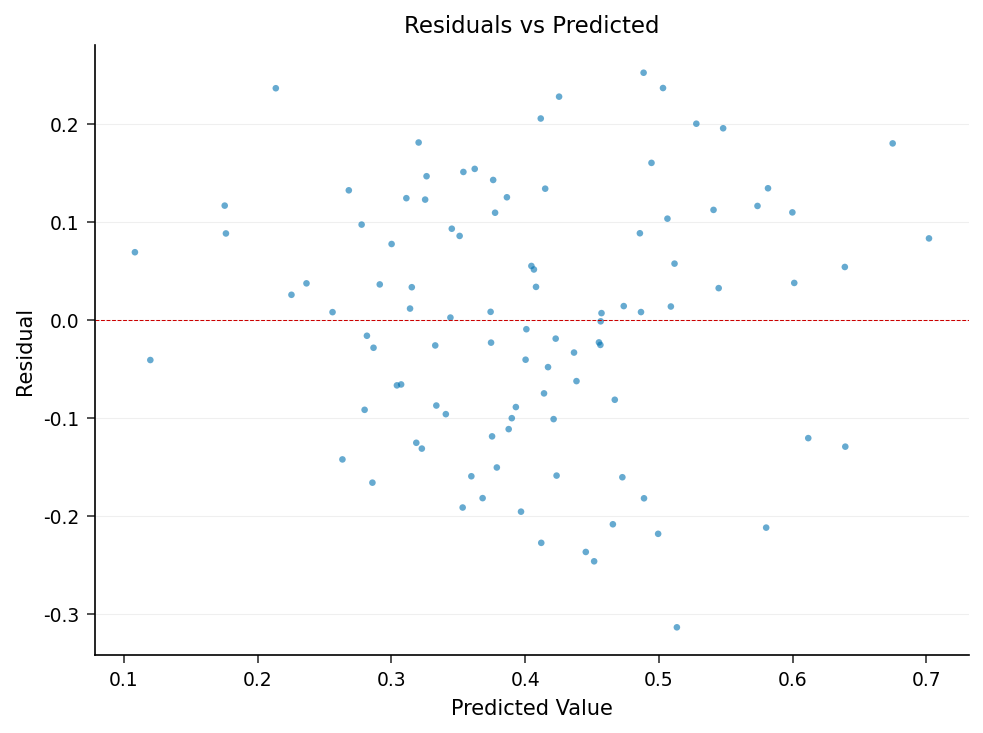

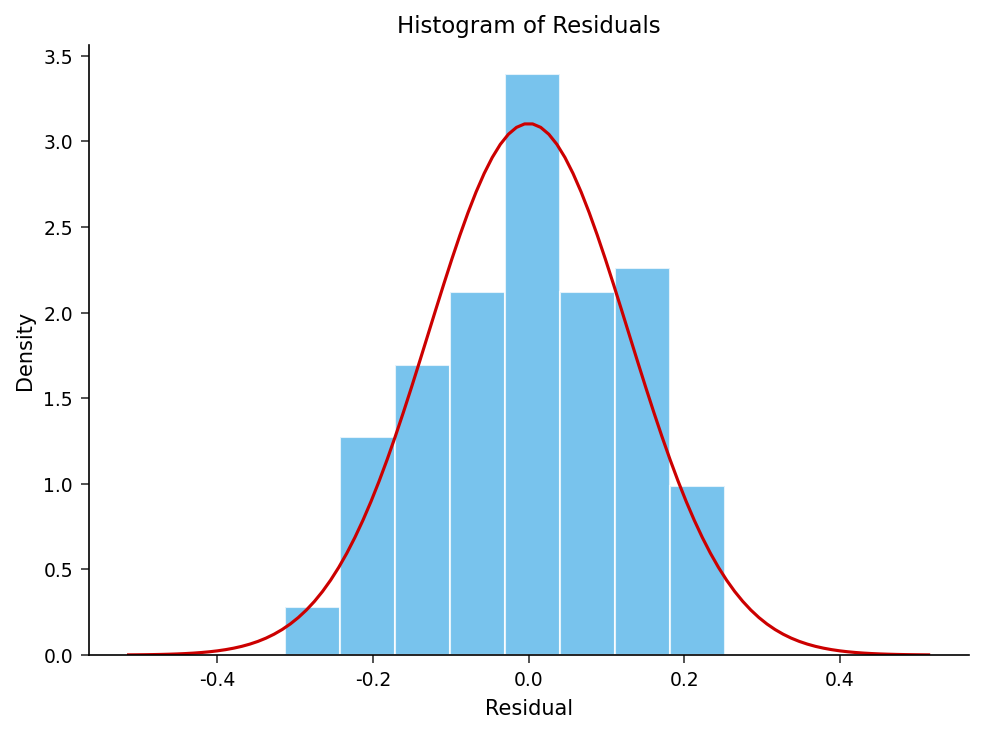

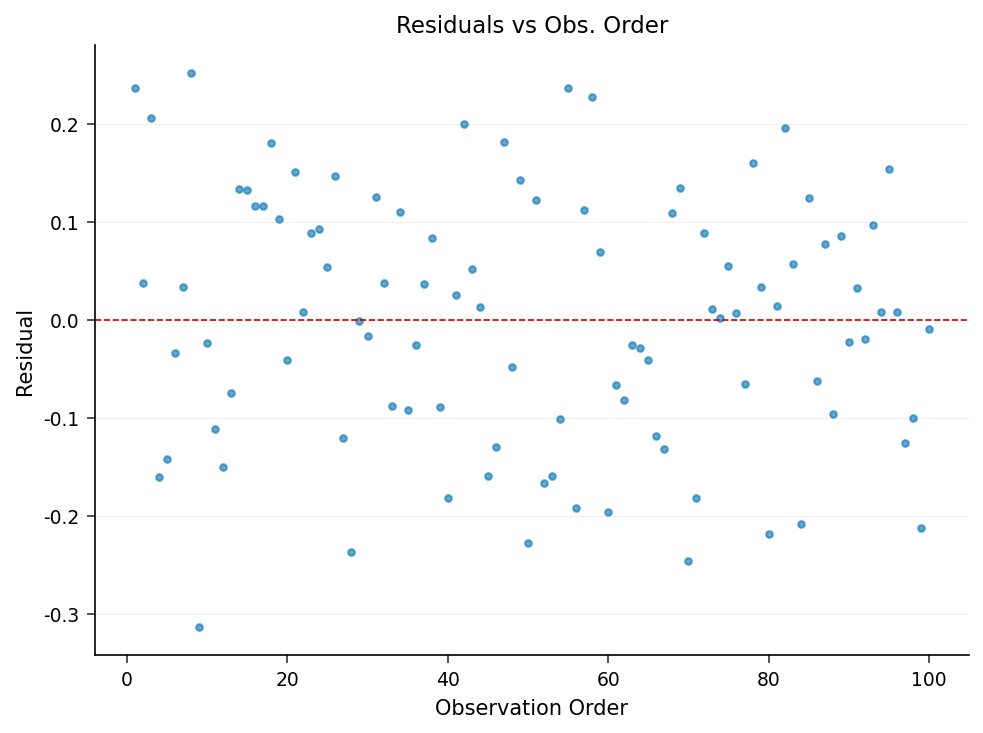

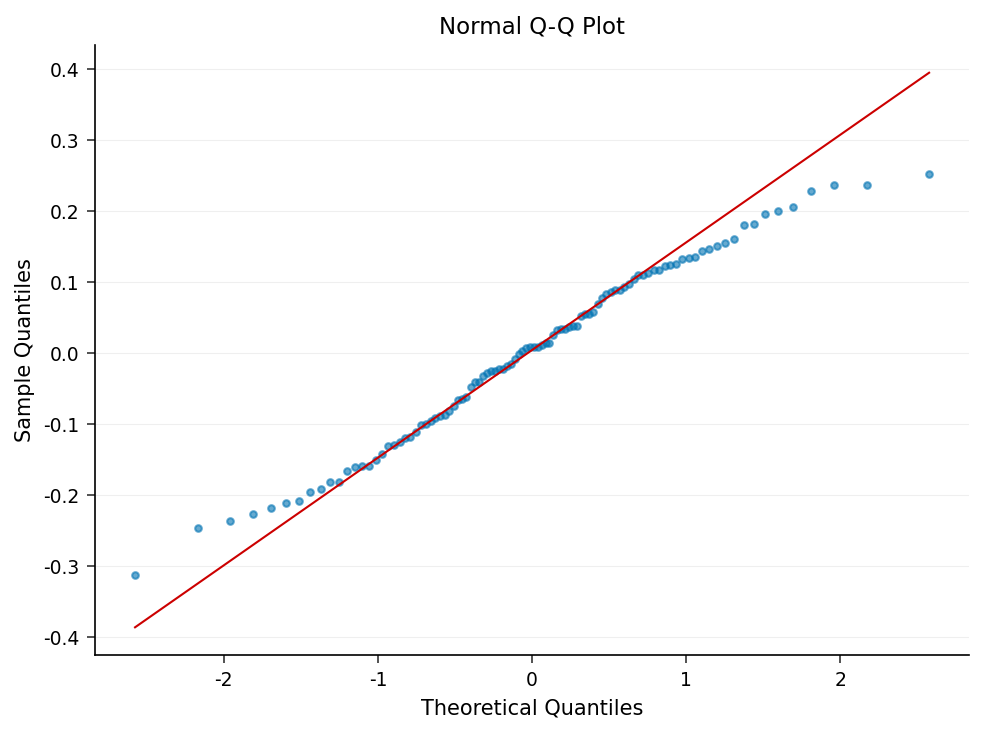

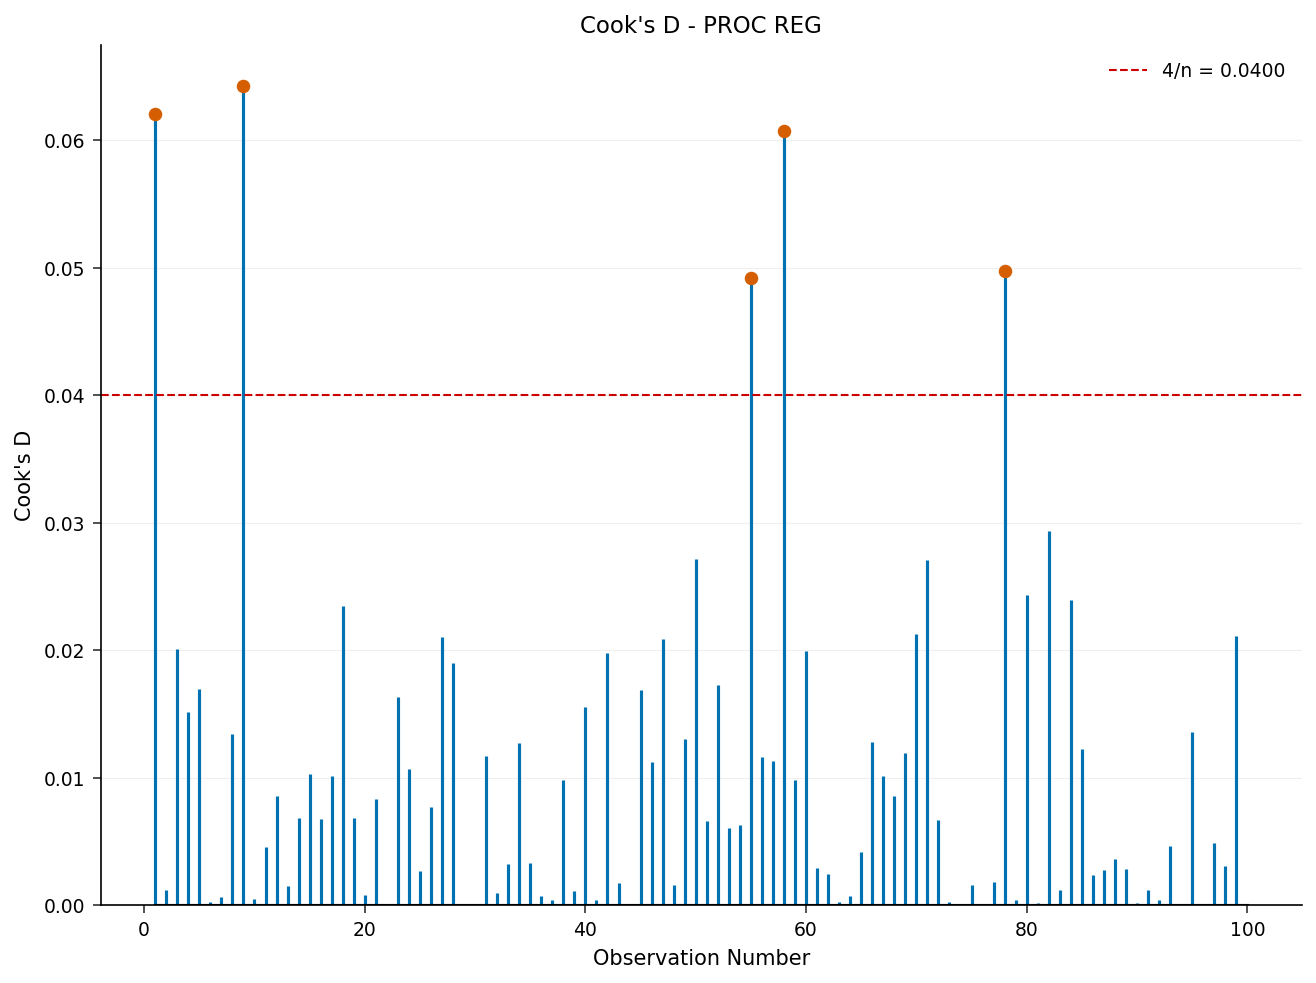

In [3]:
/* Benuttingsgraad versus kredietnemer- en macrocovariaten */
PROCEDURE REG GEGEVENS=kredietlijnen;
    MODEL benuttingsgraad =
          dscr omzet_volatiliteit eerdere_benutting
          maanden_looptijd werkloosheid korte_rente
          / clb stb vif tol;
UITVOEREN;
QUIT;


## 4. Benutting per branchesegment — algemeen lineair model

Nemen sommige branches hun lijnen agressiever op zodra we rekening houden met de kwaliteit van de kredietnemer en de macro-achtergrond? **PROC GLM** behandelt `branche` als een classificatie-effect en voegt dezelfde continue covariaten toe als covariantieanalyse-controles. We vragen:

- **SOLUTION** — de parameterschattingen voor elk brancheniveau ten opzichte van de referentie.
- **LSMEANS / PDIFF / ADJUST=TUKEY / CL** — Tukey-gecorrigeerde kleinste-kwadraten-gemiddelden en paarsgewijze verschillen, de voor covariaten gecorrigeerde benutting voor elk segment.

GLM produceert hetzelfde ODS-diagnosepaneel als REG plus een staafdiagram van kleinste-kwadraten-gemiddelden per branche (met betrouwbaarheidsintervallen), weergegeven onder de tabellen. Het is ook een RUN-groepproc, dus het eindigt met `quit;`.

                              The GLM Procedure                              
   Dependent Variable: benuttingsgraad Benuttingsgraad (opgenomen/limiet)    

Source                    DF  Sum of Squares  Mean Square   F Value    Pr > F
------------------  --------  --------------  -----------  --------  --------
branche                    4         0.15847      0.03962      2.35    0.0604
dscr                       1         0.68916      0.68916     40.83    <.0001
omzet_volatiliteit         1         0.13434      0.13434      7.96    0.0059
eerdere_benutting          1         0.43034      0.43034     25.49    <.0001
werkloosheid               1         0.14344      0.14344      8.50    0.0045
korte_rente                1         0.08861      0.08861      5.25    0.0243
Error                     90         1.51926      0.01688                    

Root MSE           0.12993    R-Square            0.4920
Adj R-Sq            0.4412

                        Parameter Estimates            


NOTE: PROC GLM data=kredietlijnen

NOTE: Warning message:
NOTE: In readLines(file("stdin")) : incomplete final line found on 'stdin'
NOTE: ODS plot written: glm_residuals_vs_predicted.spec.json
NOTE: ODS plot written: glm_residual_histogram_panel.spec.json
NOTE: ODS plot written: glm_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: glm_qq_plot.spec.json
NOTE: ODS plot written: glm_lsmeans_branche.spec.json
NOTE: PROC GLM ODS Graphics generated.
NOTE: PROC GLM statement used.


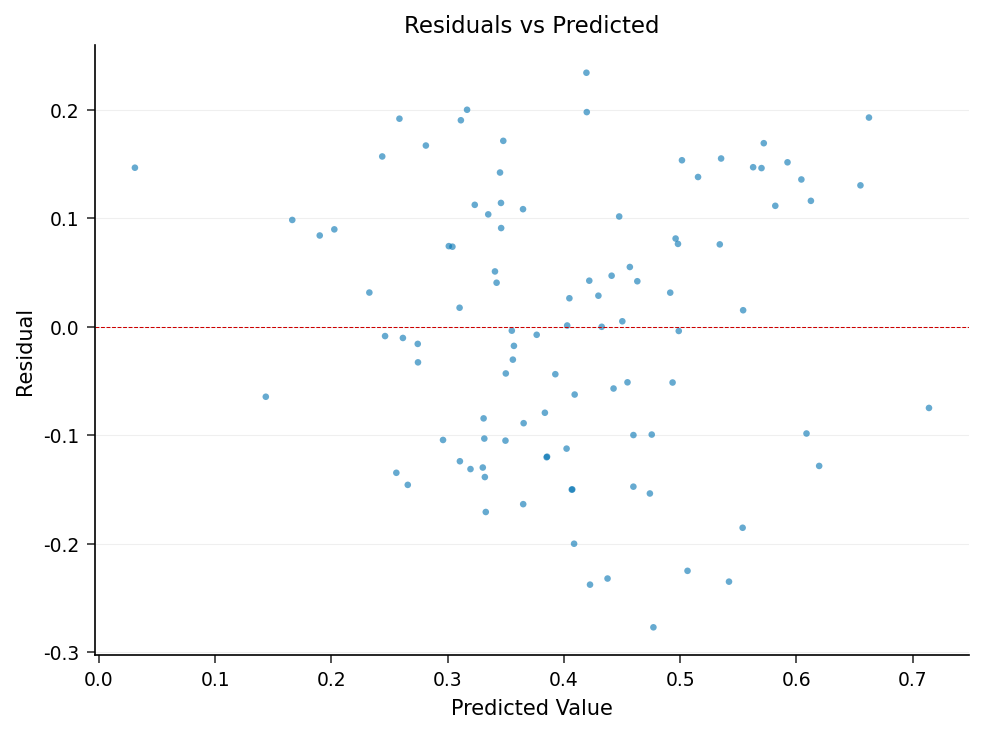

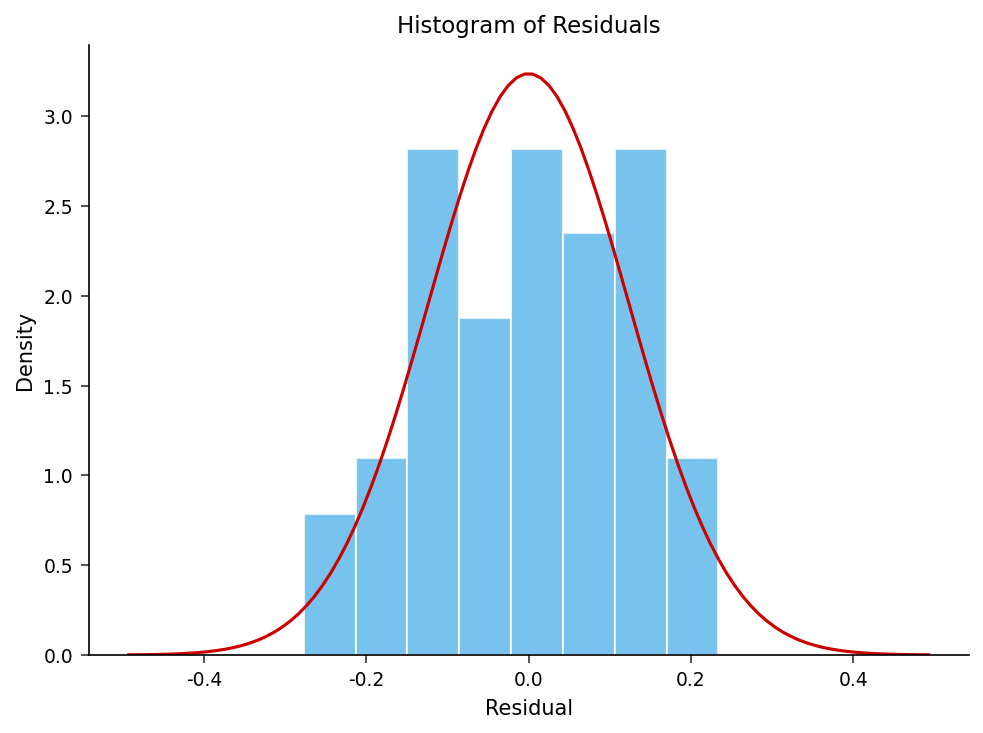

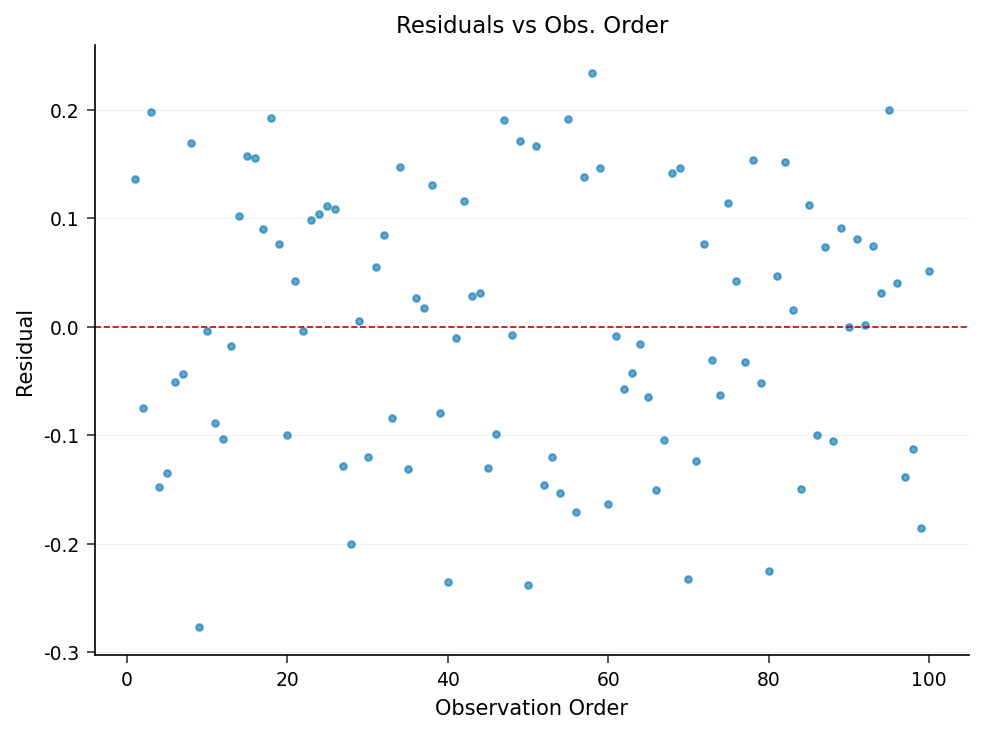

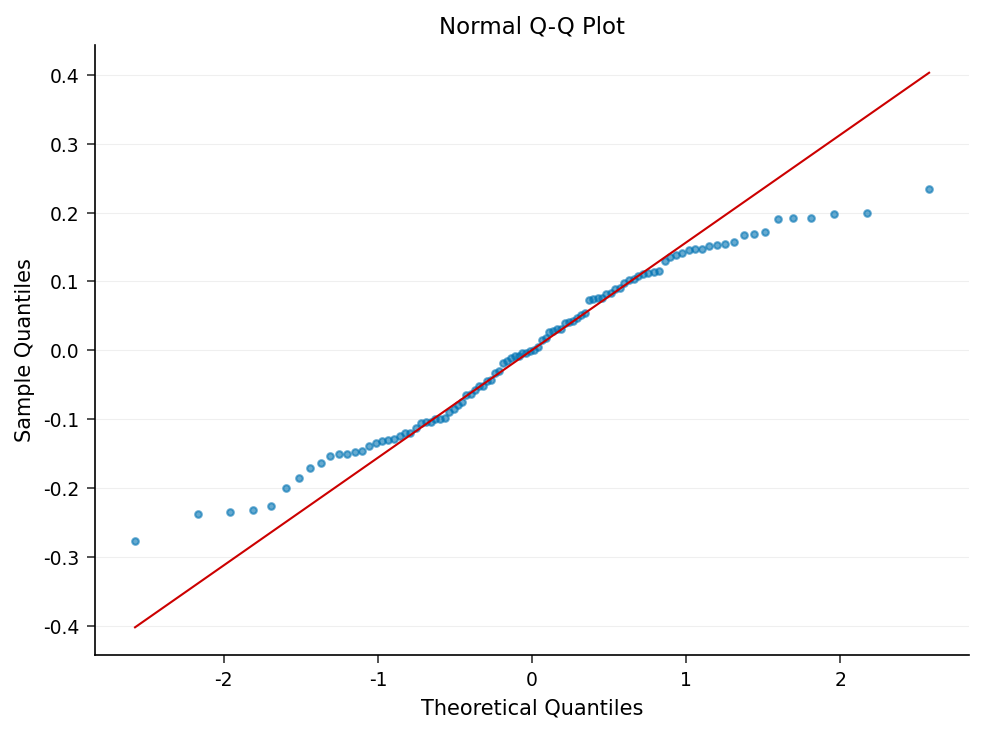

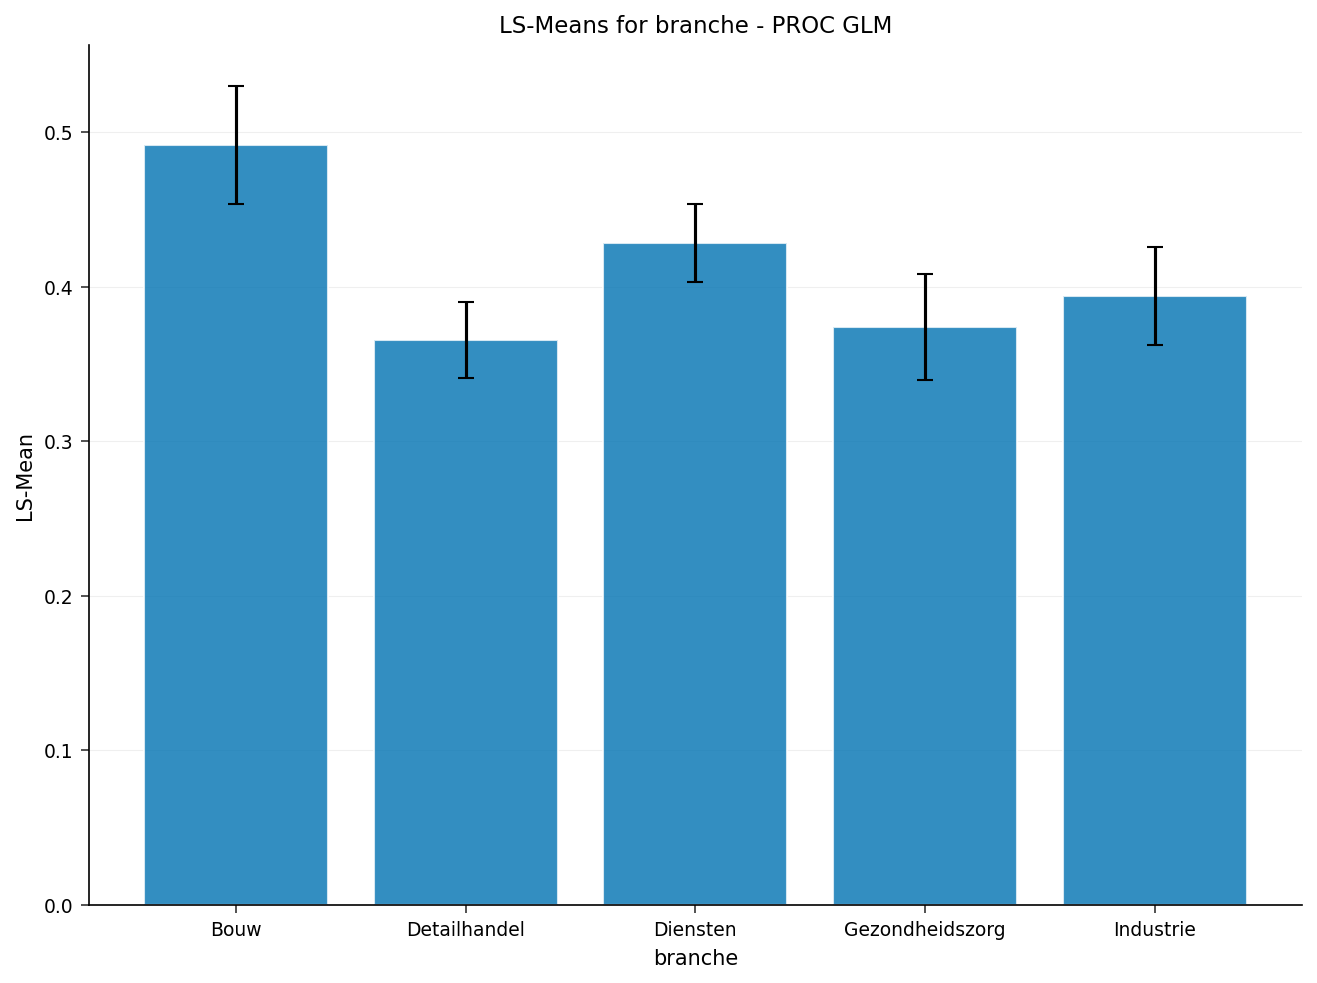

In [4]:
/* Benutting per branchesegment, gecorrigeerd voor drijvers */
PROCEDURE GLM GEGEVENS=kredietlijnen;
    KLASSE branche;
    MODEL benuttingsgraad =
          branche dscr omzet_volatiliteit eerdere_benutting
          werkloosheid korte_rente
          / SOLUTION ss3;
    LSMEANS branche / PDIFF ADJUST=TUKEY cl;
UITVOEREN;
QUIT;


## 5. Benuttingsband voor stress en economisch kapitaal

Kapitaalplanning heeft de **staarten** van de benuttingsverdeling nodig, niet alleen het gemiddelde. Omdat fractionele percentielen het best via **PROC UNIVARIATE** worden genomen in plaats van via PROC MEANS, gebruiken we `PCTLPTS=` om de **2,5e en 97,5e percentielen** van benutting te extraheren. De resulterende band definieert een plausibel laag/hoog opnamescenario voor stresstesten van het opgenomen saldo.

In [5]:
/* 2,5e / 97,5e benuttingspercentielen voor stressband */
PROCEDURE UNIVARIATE GEGEVENS=kredietlijnen NOPRINT;
    VARIABELE benuttingsgraad;
    UITVOER out=benuttings_band
           mean=util_gem
           pctlpts=2.5 97.5
           pctlpre=util_p
           pctlname=lo hi;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=benuttings_band noobs label;
    label util_gem  = "Gemiddelde benutting"
          util_plo  = "2,5e percentiel (stress laag)"
          util_phi  = "97,5e percentiel (stress hoog)";
UITVOEREN;



Gemiddelde benutting  2,5e percentiel (stress laag)  97,5e percentiel (stress hoog)
--------------------  -----------------------------  ------------------------------
            0.403738                         0.1212                          0.7438




NOTE: PROC UNIVARIATE
NOTE: Output dataset benuttings_band has 1 observations and 3 variables.
NOTE: PROC PRINT data=benuttings_band

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## 6. Interpretatie en vervolgstappen

**Wat het model laat zien**

- **Risicoklasse drijft de gefinancierde blootstelling.** Het PROC MEANS-profiel toont dat de gemiddelde benutting monotoon stijgt van de sterkste naar de zwakste klasse — 0,307 (A), 0,359 (B), 0,416 (C), 0,488 (D), 0,518 (E). Omdat het opgenomen saldo benutting maal toegezegde limiet is, zetten zwakkere klassen een groter deel van hun toezeggingen om in gefinancierde saldi — de kerninput voor blootstelling-bij-wanbetaling en economisch kapitaal voor doorlopende lijnen. (Het gemiddelde opgenomen saldo stijgt ook met de klasse en piekt bij klasse D in deze steekproef van 100 lijnen; de kleine klasse-E-cel van 9 lijnen bevat één zeer grote limiet die het gemiddelde van de toegezegde limiet vertekent, precies het soort kleine-celgedrag dat het volledige boek zou gladstrijken.)
- **Fundamentals van de kredietnemer domineren de regressie.** In PROC REG draagt **schuldendekkingsgraad** de grootste gestandaardiseerde coëfficiënt (-0,45) en werkt beschermend — elke extra eenheid dekking verlaagt de benutting met ongeveer 0,11 (95% CL -0,152 tot -0,075). **Eerdere benutting** is de op één na sterkste drijver (gestandaardiseerd 0,41, schatting +0,38): lijnen die eerder zwaar waren opgenomen blijven hoog benut. **Omzetvolatiliteit** (+0,37, p = 0,021) en de macrotermen — **werkloosheid** (+0,036, p = 0,009) en de **korte rente** (+0,036, p = 0,036) — zijn allemaal positief en significant, dus een neergang tilt mechanisch de portefeuillebrede gefinancierde saldi omhoog. Alle VIF's liggen onder 1,17, ruim onder de conventionele drempel van 10, wat bevestigt dat de drijvers niet collineair zijn, en de CLB-intervallen sluiten nul uit voor elk effect behalve de veroudering van de lijn. De residudiagnostiek gedraagt zich netjes: residuen verspreiden willekeurig rond nul, het histogram is ruwweg normaal, en de Q-Q-plot ligt dicht bij lineair met slechts milde staartafwijking; Cook's D signaleert vier matig invloedrijke lijnen (boven 4/n = 0,04) die een blik op datakwaliteit waard zijn.
- **Branche voegt een grensgeval-restsignaal toe.** Na correctie voor covariaten van kredietnemer en macro is het algehele branche-effect in PROC GLM slechts grensgeval (Type III F p = 0,060). Maar de Tukey-gecorrigeerde kleinste-kwadraten-gemiddelden scheiden de segmenten nog steeds: de **Bouw** heeft de hoogste gecorrigeerde benutting (0,492), gevolgd door **Diensten** (0,428), met **Industrie** (0,394), **Gezondheidszorg** (0,374) en **Detailhandel** (0,366) daaronder geclusterd. De paarsgewijze toetsen bevestigen dat de Bouw significant meer opneemt dan de **Detailhandel** (verschil 0,126, p = 0,007) en de **Gezondheidszorg** (0,118, p = 0,024); de overige paarsgewijze verschillen zijn niet significant. Dit strookt met hoe de werkkapitaalintensiteit per sector varieert en markeert de Bouw als het segment om in de gaten te houden.

**Hoe het te gebruiken**

- **Voorspel gefinancierde saldi** door de regressie toe te passen op toekomstige macropaden (stijgende werkloosheid, hogere korte rentes) om het opgenomen saldo van de portefeuille onder elk scenario te projecteren.
- **Stel de economisch-kapitaalstressband** vast op basis van de PROC UNIVARIATE-percentielen: benutting varieert plausibel van **0,121** (2,5e) tot **0,744** (97,5e) rond een gemiddelde van 0,404, wat het lage/hoge opnamescenario voor een neergang bepaalt.
- **Differentieer limieten en prijsstelling** per risicoklasse en per de verhoogde gecorrigeerde opname van de Bouw, door te belasten voor de hogere verwachte benutting — en hogere gefinancierde blootstelling — die de MEANS- en GLM-resultaten kwantificeren.

**Uitbreidingen**

Vervang de OLS-koppeling door een fractionele-respons- of bèta-regressie (PROC GLIMMIX / PROC NLMIXED) om de 0–1-grens te respecteren, voeg een willekeurig kredietnemereffect toe voor panels over meerdere perioden, en voer de gefitte benutting rechtstreeks in een verlies-bij-wanbetaling- en economisch-kapitaalmotor. Het opnieuw draaien op het volledige (onbegrensde) boek zou de kleine risicoklasse- en branchecellen aanscherpen en de grensgeval-branche-F-toets waarschijnlijk verscherpen.